## Getting Started 

1. Import all required libraries at the top of your notebook.
2. Load your chosen dataset and inspect it (`.info()`, `.describe()`, value counts for the grouping variable).
3. Drop or impute missing values, documenting your decision.
4. Identify the **outcome variable** (continuous) and the **grouping variable** (categorical, ≥ 3 levels).

In [1]:
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier 
import numpy as np 

In [34]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [29]:
from scipy.stats import levene, shapiro, f_oneway, probplot
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [21]:
from scipy.stats import f_oneway

In [2]:
df = sns.load_dataset("penguins")
print(df.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
df.describe

<bound method NDFrame.describe of     species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
3    Adelie  Torgersen             NaN            NaN                NaN   
4    Adelie  Torgersen            36.7           19.3              193.0   
..      ...        ...             ...            ...                ...   
339  Gentoo     Biscoe             NaN            NaN                NaN   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    Male  

In [5]:
df.isna().sum() 

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [6]:
df.shape 

(344, 7)

In [7]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [8]:
df = df.dropna(subset=[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
], how="all")

In [9]:
# If all 4 are NaN, that row has almost no usable signal. So i dropped these two raws. 

In [10]:
# the next thing that  will do is to train model and fill those nans with the outputs that tthe model generated with more than 90% confident. 

In [11]:
train_df = df[df["sex"].notna()]
test_df = df[df["sex"].isna()]

features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X_train = train_df[features]
y_train = train_df["sex"]

model = RandomForestClassifier()
model.fit(X_train, y_train) 

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
probs = model.predict_proba(test_df[features])
preds = model.predict(test_df[features])

In [13]:
confidence = probs.max(axis=1)

mask = confidence >= 0.9

df.loc[test_df.index[mask], "sex"] = preds[mask]

In [14]:
df.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  3
dtype: int64

In [15]:
# now i have 3 nans which is useless so i will drop them. 

In [16]:
df.dropna(subset=["sex"], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_16620\2793066291.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=["sex"], inplace=True)


In [17]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [18]:
## outcome variable
# bill_length_mm	
# bill_depth_mm
# flipper_length_mm
# body_mass_g 

## grouping variable
# species	
# island
# sex 

### Task 1: One-Way ANOVA 

1. Split the outcome variable into separate arrays (or use a groupby), one per level of the grouping variable.
2. Run a one-way ANOVA using `scipy.stats.f_oneway`. 
3. Record the F-statistic and p-value. 
4. In a markdown cell, interpret the result:
   - State the null and alternative hypotheses in plain language.
   - Based on the p-value (use α = 0.05), do you reject or fail to reject the null?
   - What does the F-statistic tell you about the ratio of between-group to within-group variance?

In [26]:
# Split body_mass_g by species
adelie = df[df["species"] == "Adelie"]["body_mass_g"]
chinstrap = df[df["species"] == "Chinstrap"]["body_mass_g"]
gentoo = df[df["species"] == "Gentoo"]["body_mass_g"]

In [27]:
groups = [group["body_mass_g"].values for name, group in df.groupby("species")]

In [28]:
# Using separate arrays
f_stat, p_val = f_oneway(adelie, chinstrap, gentoo)

# Or using groupby result
# f_stat, p_val = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_val)

F-statistic: 339.45154335363327
p-value: 2.216512966333082e-81


**Null hypothesis (H0):** The mean body mass is the same across all penguin species.  
**Alternative hypothesis (H1):** At least one species has a different mean body mass.

**Decision:**  
- If `p-value < 0.05` → reject H0  
- If `p-value ≥ 0.05` → fail to reject H0

**F-statistic interpretation:**  
- It is the ratio of **variance between groups** to **variance within groups**.  
- A higher F means that the group means differ more than the variation within each group, suggesting a significant effect of species on body mass.

In [30]:
# Using the same groups as before
f_levene, p_levene = levene(adelie, chinstrap, gentoo)
print("Levene test statistic:", f_levene)
print("p-value:", p_levene)

Levene test statistic: 5.419909661107927
p-value: 0.004823194552686151


If p-value > 0.05 → fail to reject H0 → assumption of equal variance is reasonable.  
If p-value ≤ 0.05 → reject H0 → variances are not equal; consider alternatives like **Welch's ANOVA**.

In [31]:
for name, group in df.groupby("species"):
    stat, p = shapiro(group["body_mass_g"])
    print(f"{name}: Shapiro-Wilk p-value = {p}")

Adelie: Shapiro-Wilk p-value = 0.03405255426453537
Chinstrap: Shapiro-Wilk p-value = 0.5605082387697975
Gentoo: Shapiro-Wilk p-value = 0.22729989657853977


In [32]:
# Compute group means
group_means = df.groupby("species")["body_mass_g"].transform("mean")
residuals = df["body_mass_g"] - group_means

# Shapiro-Wilk on residuals
stat_res, p_res = shapiro(residuals)
print("Residuals Shapiro-Wilk p-value:", p_res)

Residuals Shapiro-Wilk p-value: 0.05398363340917667


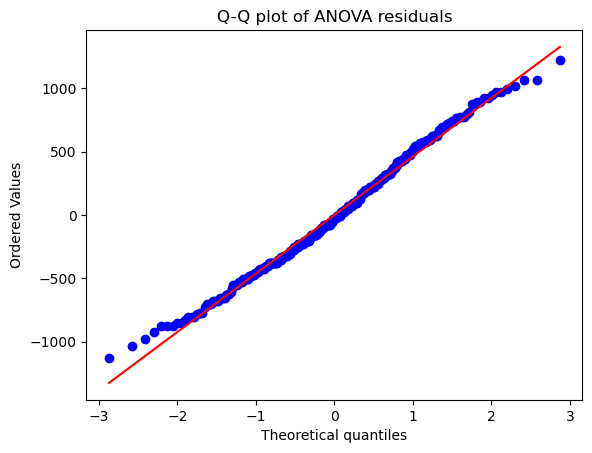

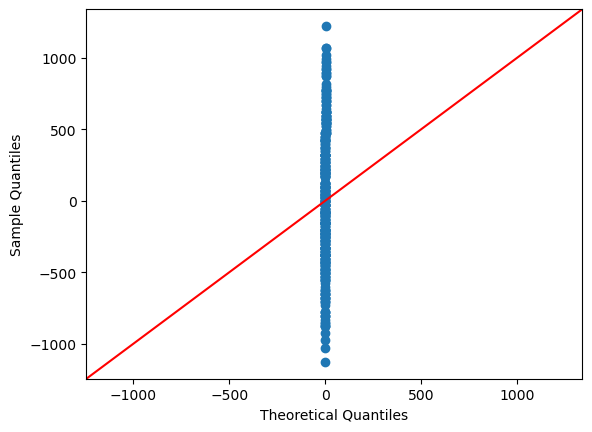

In [33]:
# Using scipy
probplot(residuals, plot=plt)
plt.title("Q-Q plot of ANOVA residuals")
plt.show()

# Or using statsmodels
sm.qqplot(residuals, line='45')
plt.show()

**Normality of residuals:**  
- If p-value > 0.05 and Q-Q plot roughly linear → residuals approximately normal  
- If p-value ≤ 0.05 or strong deviations in Q-Q → normality is questionable

**Alternatives if assumptions fail:**  
- Unequal variances → **Welch's ANOVA**  
- Non-normal residuals → **Kruskal-Wallis test** (non-parametric)

In [35]:
# Load data (if not already done)
df = sns.load_dataset("penguins")
df.dropna(subset=["body_mass_g", "species"], inplace=True)

# Tukey HSD
tukey = pairwise_tukeyhsd(endog=df["body_mass_g"],   # outcome
                          groups=df["species"],     # grouping variable
                          alpha=0.05)              # significance level

# Print summary table
print(tukey.summary())

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------


**Interpretation:**  
- Pairs with `reject=True` → significantly different means  
- Pairs with `reject=False` → not significantly different  
- Confidence intervals tell you the practical size of differences (large difference = wider gap between CI, small difference = overlapping CI)

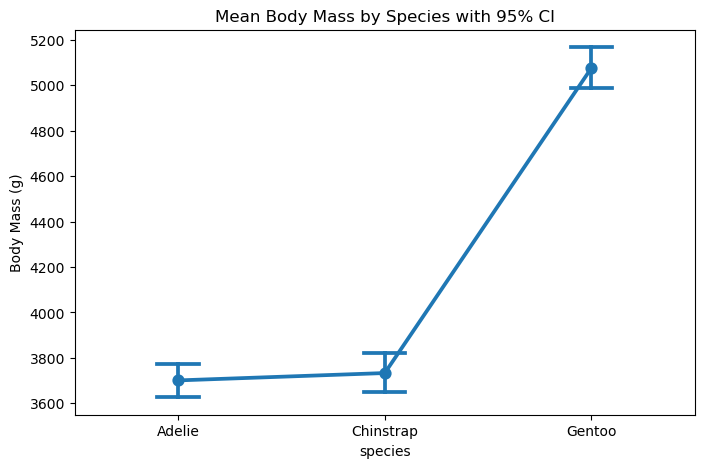

In [36]:
# Convert Tukey results to a DataFrame
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))

# Tukey provides lower & upper CI for the difference, but for a simple mean plot:
# Plot group means with 95% CI
sns.pointplot(x="species", y="body_mass_g", data=df, capsize=0.2)
plt.title("Mean Body Mass by Species with 95% CI")
plt.ylabel("Body Mass (g)")
plt.show()

**Significant pairs:**  
- Adelie vs Gentoo → reject = True  
- Chinstrap vs Gentoo → reject = True  

**Non-significant pairs:**  
- Adelie vs Chinstrap → reject = False  

**Practical interpretation:**  
- Gentoo penguins are heavier than the other two species.  
- Adelie and Chinstrap are not significantly different.  
- Confidence intervals show the magnitude of difference and whether groups overlap.